# Open Field Test — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)

This notebook demonstrates two example sessions from the Open Field Test (OFT) dataset:

- **Example 1 — VAME behavioral motifs:** An Anxa1-Flp mouse (Tetanus toxin model) with pose
  estimation and VAME motif labelling (`VAME_42`, 42 k-means clusters).
- **Example 2 — Fiber photometry + kinematics:** A WT mouse from the `oft_fp`
  sub-experiment with simultaneous dLight1.3b fiber photometry (dCP) and derived kinematics.

## About the experiment

Mice explored a 40×40 cm arena with a transparent floor, recorded from below at 30 fps.
The OFT was used to study locomotion and behavioral motifs in mouse models of Parkinson's disease.
Seven sub-experiments were conducted across multiple dopamine-related genetic and lesion models
(6-OHDA, Anxa1-TetTox, MitoPark, anti-Anxa1 antibody).

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Video** | `acquisition/Video {name}` | 30 fps | External reference to MP4 file (not embedded) |
| **Pose estimation** | `processing/behavior/PoseEstimationDeepLabCut` | 30 Hz | DeepLabCut output — 6 keypoints (x, y, confidence) |
| **VAME motifs** | `processing/behavior/VAME_42` | 30 Hz | `VAMEProject` container with a `MotifSeries` (HMM segmentation, 42 k-means clusters, labels 0–41); access via `project.motif_series["MotifSeries"]` |
| **Fiber photometry — dF/F** | `processing/ophys/FiberPhotometrySeriesDfOverF` | ~60 Hz | Isosbestic-corrected dF/F (470 nm minus scaled 405 nm reference); canonical processed signal |
| **Fiber photometry — z-scored** | `processing/ophys/FiberPhotometrySeriesZScored` | 30 Hz | Session-level z-scored FP signal aligned to behavioral frames; used for peri-event analyses in the publication |
| **Fiber photometry — raw 470 nm** | `acquisition/FiberPhotometrySeriesRawSignal` | ~60 Hz | Raw 470 nm fluorescence (dopamine-sensitive channel, DoricStudio V5 output) |
| **Fiber photometry — raw 405 nm** | `acquisition/FiberPhotometrySeriesIsosbesticControl` | ~60 Hz | Raw 405 nm isosbestic fluorescence (motion/photobleaching reference channel) |
| **Kinematics** | `processing/behavior/Kinematics` | 30 Hz | Derived speed, acceleration, angular speed, distance metrics |

Not all streams are present in every session. Fiber photometry streams are only available in the
`oft_fp` sub-experiment (31 of 161 sessions). VAME motifs are available for most sessions.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

In [2]:
def _plot_ethogram(ax, time, rank_labels, yticks, rate):
    """Pcolormesh ethogram: one coloured cell per frame, blank everywhere else.

    Each column in the grid corresponds to one video frame; exactly one row
    (the active motif) is coloured per column. This makes it unambiguous that
    only one motif is active at a time and that the x-axis is recording time.
    """
    n_m = len(yticks)
    n_f = len(rank_labels)
    img = np.full((n_m, n_f), np.nan)
    img[rank_labels, np.arange(n_f)] = rank_labels.astype(float)
    dt = 1.0 / rate
    ax.pcolormesh(
        np.append(time - dt / 2, time[-1] + dt / 2),
        np.arange(-0.5, n_m + 0.5),
        np.ma.masked_invalid(img),
        cmap="tab20b", vmin=0, vmax=n_m - 1,
        shading="flat", rasterized=True,
    )


## Example 1: Behavioral motifs session

This session (sub-687643, Anxa1-Flp, Tetanus toxin / TetTox model) contains video,
pose estimation, and VAME motif labelling (`VAME_42`, 42 motif labels).

In [20]:
nwb_path_vame = "../../../nwb_output/open_field_test/sub-687643/sub-687643_ses-oft-2023-05-16T15-31-06.nwb"

io1 = NWBHDF5IO(nwb_path_vame, mode="r")
nwbfile1 = io1.read()

print(f"Session ID:    {nwbfile1.session_id}")
print(f"Session start: {nwbfile1.session_start_time}")
print(f"Subject ID:    {nwbfile1.subject.subject_id}")
print(f"Genotype:      {nwbfile1.subject.genotype}")
print(f"Sex:           {nwbfile1.subject.sex}")
print(f"Institution:   {nwbfile1.institution}")
print(f"Lab:           {nwbfile1.lab}")

Session ID:    oft-2023-05-16T15-31-06
Session start: 2023-05-16 15:31:06+02:00
Subject ID:    687643
Genotype:      anxa1-flp
Sex:           M
Institution:   Karolinska Institutet
Lab:           Meletis


### 1.1 Video (external reference)

Videos are stored as external file references rather than embedded pixel data.
Each session has one MP4 video (H.264, 30 fps, ~856×818 pixels) recorded from below
through a transparent floor.

In [21]:
video_key = next(k for k in nwbfile1.acquisition if k.startswith("Video"))
video = nwbfile1.acquisition[video_key]
print(f"Video name:    {video.name}")
print(f"External file: {video.external_file[0]}")
print(f"Starting time: {video.starting_time} s")
print(f"Rate:          {video.rate} fps")

Video name:    Video oft_2023-05-16T15_31_06
External file: /Volumes/T9/data/Meletis/oft/videos/oft_2023-05-16T15_31_06.mp4
Starting time: 0.0 s
Rate:          30.0 fps


### 1.2 Pose estimation (DeepLabCut)

Pose estimation was performed using DeepLabCut, tracking 6 keypoints on each mouse:
**snout**, **left front paw**, **right front paw**, **left back paw**, **right back paw**,
and **tail base**. Stored via the [ndx-pose](https://github.com/rly/ndx-pose) extension.

Each keypoint has:
- `data` — (N, 2) array of (x, y) pixel coordinates at 30 Hz
- `confidence` — (N,) array of DLC likelihood scores per frame

In [22]:
behavior1 = nwbfile1.processing["behavior"]
pose = behavior1["PoseEstimationDeepLabCut"]

keypoint_names = [k.replace("PoseEstimationSeries", "") for k in pose.pose_estimation_series]
print(f"Keypoints ({len(keypoint_names)}): {keypoint_names}")
print(f"Scorer: {pose.scorer}")
print(f"Source software: {pose.source_software}")

snout = pose.pose_estimation_series["PoseEstimationSeriesSnout"]
print(f"\nSnout data shape: {snout.data.shape}  (frames × [x, y])")
print(f"Confidence shape: {snout.confidence.shape}")
print(f"Number of frames: {snout.data.shape[0]}")

Keypoints (6): ['Leftbackpaw', 'Leftfrontpaw', 'Rightbackpaw', 'Rightfrontpaw', 'Snout', 'Tailbase']
Scorer: DLC_resnet50_oft_roomIVASep13shuffle1_950000
Source software: DeepLabCut

Snout data shape: (9000, 2)  (frames × [x, y])
Confidence shape: (9000,)
Number of frames: 9000


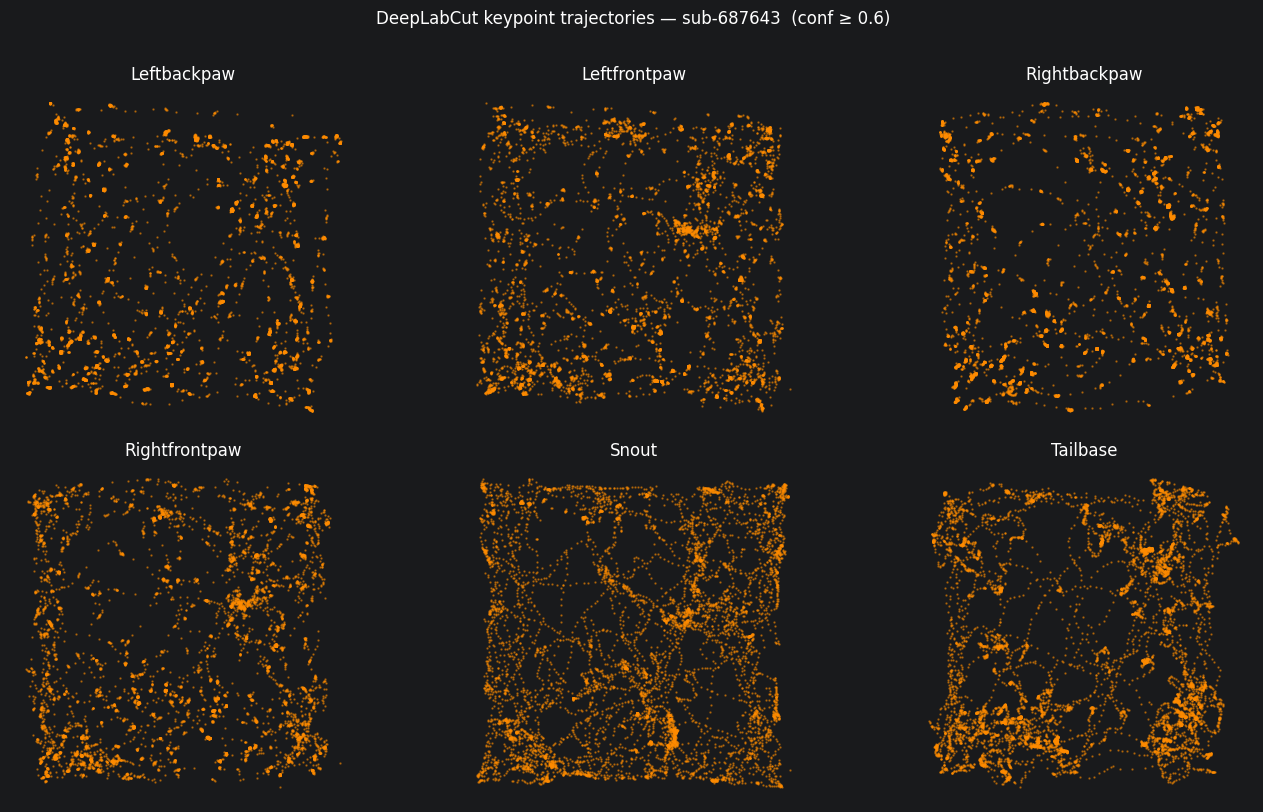

In [23]:
def _valid_mask(xy, conf, conf_thresh=0.6, iqr_scale=3.0):
    """Keep frames with high confidence and within 3×IQR of the median position."""
    mask = conf >= conf_thresh
    for dim in range(2):
        vals = xy[mask, dim]
        q25, q75 = np.percentile(vals, [25, 75])
        iqr = q75 - q25
        mask &= (xy[:, dim] >= q25 - iqr_scale * iqr) & (xy[:, dim] <= q75 + iqr_scale * iqr)
    return mask

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (key, pes) in zip(axes.flat, pose.pose_estimation_series.items()):
    xy = pes.data[:]
    conf = pes.confidence[:]
    mask = _valid_mask(xy, conf)
    ax.scatter(xy[mask, 0], xy[mask, 1], c="darkorange", s=0.5, alpha=0.5)
    ax.set_title(f"{key.replace('PoseEstimationSeries', '')}")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.invert_yaxis()

plt.suptitle("DeepLabCut keypoint trajectories — sub-687643  (conf ≥ 0.6)", y=1.01)
plt.tight_layout()
plt.show()

### 1.3 VAME behavioral motifs

[VAME](https://github.com/EthoML/VAME) (Variational Animal Motion Embedding) was applied for
unsupervised behavioral classification. Each frame is assigned an integer motif label (0–41) via
k-means clustering of the VAME latent space. One VAME model was applied:

- **`VAME_42`** — 42 k-means clusters, stored in `processing/behavior/VAME_42`

The `VAMEProject` container holds a `LabelledDict` of `MotifSeries` objects keyed by name.
Access labels via `project.motif_series["MotifSeries"].data[:]`.

In [24]:
vame_project = nwbfile1.processing["behavior"]["VAME_42"]

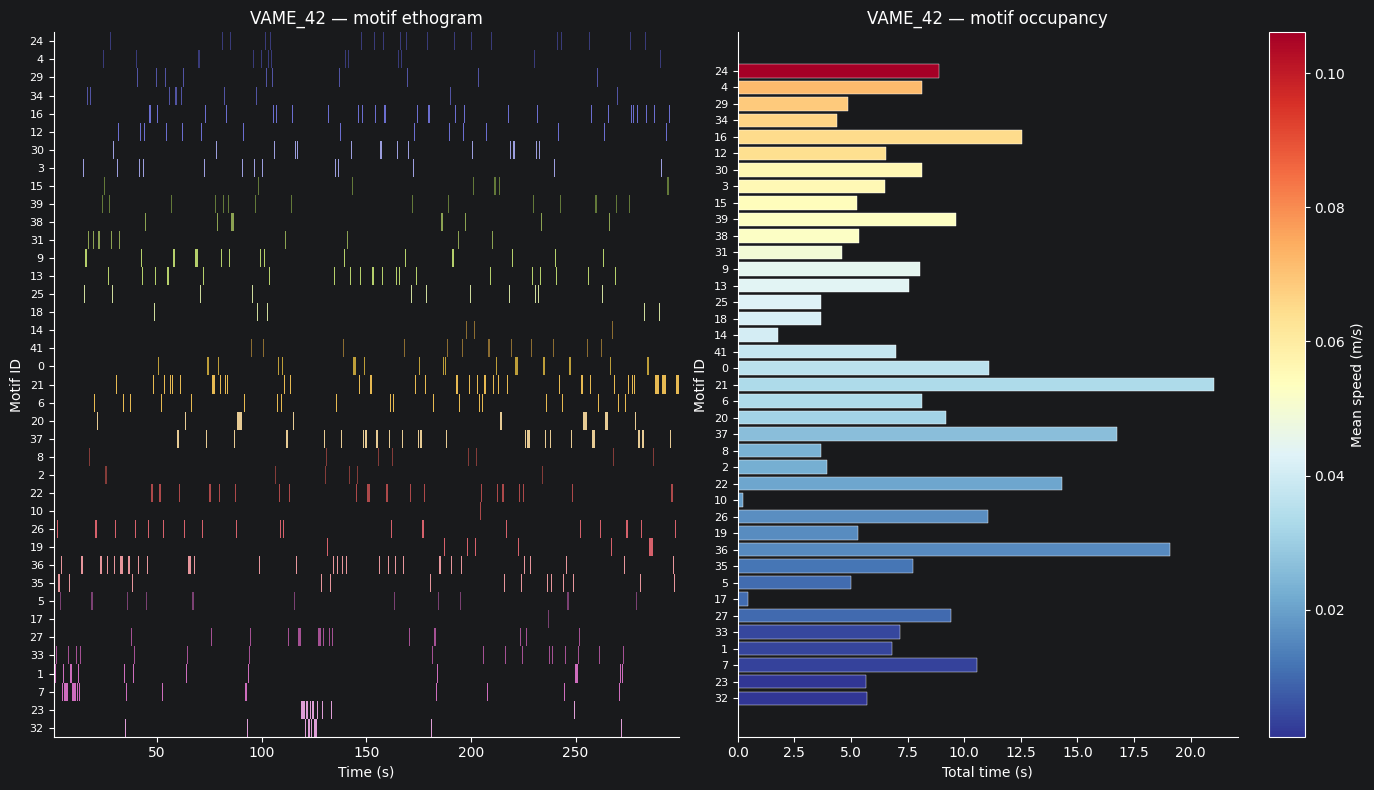

VAME_42:
  MotifSeries name:       MotifSeries
  Algorithm:              hmm
  Shape:                  (8970,)  (299.0 s at 30.000000000000007 Hz)
  Unique motifs:          39  (labels 0–41)
  Pose estimation linked: True



In [25]:
ms = vame_project.motif_series["MotifSeries"]
labels = np.array(ms.data[:])
time_s = ms.get_timestamps()

unique, counts = np.unique(labels, return_counts=True)

# sort motifs by mean speed (fast → slow)
_ts1 = behavior1["Kinematics"].time_series["linear_velocity"]
speed1 = _ts1.data[:] * _ts1.conversion
motif_mean1 = np.array([np.nanmean(speed1[labels == m]) for m in unique])
sort_idx1 = np.argsort(np.where(np.isfinite(motif_mean1), motif_mean1, -np.inf))[::-1]
sorted_ids1 = unique[sort_idx1]
sorted_counts1 = counts[sort_idx1]
sorted_means1 = motif_mean1[sort_idx1]

rank_map1 = {m: r for r, m in enumerate(sorted_ids1)}
rank_labels1 = np.array([rank_map1[l] for l in labels])
yticks1 = np.arange(len(sorted_ids1))

norm1 = plt.Normalize(np.nanmin(sorted_means1), np.nanmax(sorted_means1))
bar_colors1 = plt.cm.RdYlBu_r(norm1(sorted_means1))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

_plot_ethogram(axes[0], time_s, rank_labels1, yticks1, ms.rate)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Motif ID")
axes[0].set_yticks(yticks1)
axes[0].set_yticklabels(sorted_ids1, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title(f"VAME_42 — motif ethogram")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(yticks1, sorted_counts1 / ms.rate, color=bar_colors1, edgecolor="white", linewidth=0.3)
axes[1].set_yticks(yticks1)
axes[1].set_yticklabels(sorted_ids1, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_ylabel("Motif ID")
axes[1].set_xlabel("Total time (s)")
axes[1].set_title(f"VAME_42 — motif occupancy")
axes[1].spines[["top", "right"]].set_visible(False)
sm1 = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=norm1)
plt.colorbar(sm1, ax=axes[1], label="Mean speed (m/s)")

plt.tight_layout()
plt.show()

print(f"VAME_42:")
print(f"  MotifSeries name:       {ms.name}")
print(f"  Algorithm:              {ms.algorithm}")
print(f"  Shape:                  {labels.shape}  ({labels.shape[0] / ms.rate:.1f} s at {ms.rate} Hz)")
print(f"  Unique motifs:          {len(np.unique(labels))}  (labels {labels.min()}–{labels.max()})")
print(f"  Pose estimation linked: {vame_project.pose_estimation is not None}")
print()


## Example 2: Fiber photometry + kinematics session

This session (sub-776770, WT, `dLight_dStr` group, `oft_fp` sub-experiment) has simultaneous
fiber photometry recording (dLight1.3b sensor, fiber implanted in the dorsal caudoputamen)
alongside pose estimation and derived kinematics.

In [9]:
nwb_path_fp = "../../../nwb_output/open_field_test/sub-776770/sub-776770_ses-oft-2024-04-11T08-38-14.nwb"

io2 = NWBHDF5IO(nwb_path_fp, mode="r")
nwbfile2 = io2.read()

print(f"Session ID:    {nwbfile2.session_id}")
print(f"Session start: {nwbfile2.session_start_time}")
print(f"Subject ID:    {nwbfile2.subject.subject_id}")
print(f"Genotype:      {nwbfile2.subject.genotype}")
print(f"Sex:           {nwbfile2.subject.sex}")
print(f"Institution:   {nwbfile2.institution}")
print(f"Lab:           {nwbfile2.lab}")

Session ID:    oft-2024-04-11T08-38-14
Session start: 2024-04-11 08:38:14+02:00
Subject ID:    776770
Genotype:      WT
Sex:           U
Institution:   Karolinska Institutet
Lab:           Meletis


### 2.1 Fiber photometry

Fiber photometry recorded dopamine/calcium dynamics in `oft_fp` sessions (31 of 161).
Three signals are stored per session:

- **`processing/ophys/FiberPhotometrySeriesDfOverF`** (~60 Hz) — isosbestic-corrected dF/F (470 nm − scaled 405 nm reference)
- **`acquisition/FiberPhotometrySeriesRawSignal`** (~60 Hz) — raw 470 nm fluorescence (dopamine-sensitive)
- **`acquisition/FiberPhotometrySeriesIsosbesticControl`** (~60 Hz) — raw 405 nm isosbestic reference (motion/photobleaching control)

| Group | Location | Indicator | Fiber insertion |
|-------|----------|-----------|-----------------|
| `dLight_dStr` | Dorsal caudoputamen | dLight1.3b | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `dLight_vStr` | Central caudoputamen | dLight1.3b | cCP (AP +0.38, ML +2.0, DV −2.9) |
| `fp_dat` / `dat-cre` | Dorsal caudoputamen | jGCaMP8m | dCP |
| `fp_anxa1` / `anxa1-flp` | Dorsal caudoputamen | jGCaMP8m | dCP |

**Note:** Timestamps start at ~5–8 s due to system warm-up. Video and FP clocks are
synchronized by Bonsai at session start.

In [10]:
fp = nwbfile2.processing["ophys"]["FiberPhotometrySeriesDfOverF"]
signal = fp.data[:]
timestamps = fp.timestamps[:]

print(f"Description: {fp.description}")
print(f"Unit: {fp.unit}")
print(f"Data shape: {signal.shape}")
print(f"Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
print(f"Sampling rate: ~{1 / np.median(np.diff(timestamps)):.1f} Hz")

fp_meta = nwbfile2.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table
print(f"\nRecording location:    {fp_table['location'][0]}")
print(f"Excitation wavelength: {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:   {fp_table['emission_wavelength_in_nm'][0]} nm")

Description: Isosbestic-corrected dF/F fiber photometry signal for indicator dLight1.3b. Preprocessing in DoricStudio V5: raw 470 nm and 405 nm fluorescence traces were baseline-normalized (dF/F) and low-pass filtered (10 Hz cutoff); the normalized 405 nm isosbestic trace was then scaled to the 470 nm baseline and subtracted to remove shared artifacts (motion, photobleaching). Acquired via interleaved 470/405 nm LED excitation at ~60 Hz. Corrected dF/F traces were aligned to behavioral events (VAME motif onsets) for downstream peri-event analyses. Original signal column: ("sig" 755.58125_Df * 1) - ("ref" 537.34375_Df * 1).
Unit: a.u.
Data shape: (75731,)
Time range: 6.85 – 1269.02 s
Sampling rate: ~60.0 Hz

Recording location:    Dorsal caudoputamen
Excitation wavelength: 470.0 nm
Emission wavelength:   525.0 nm


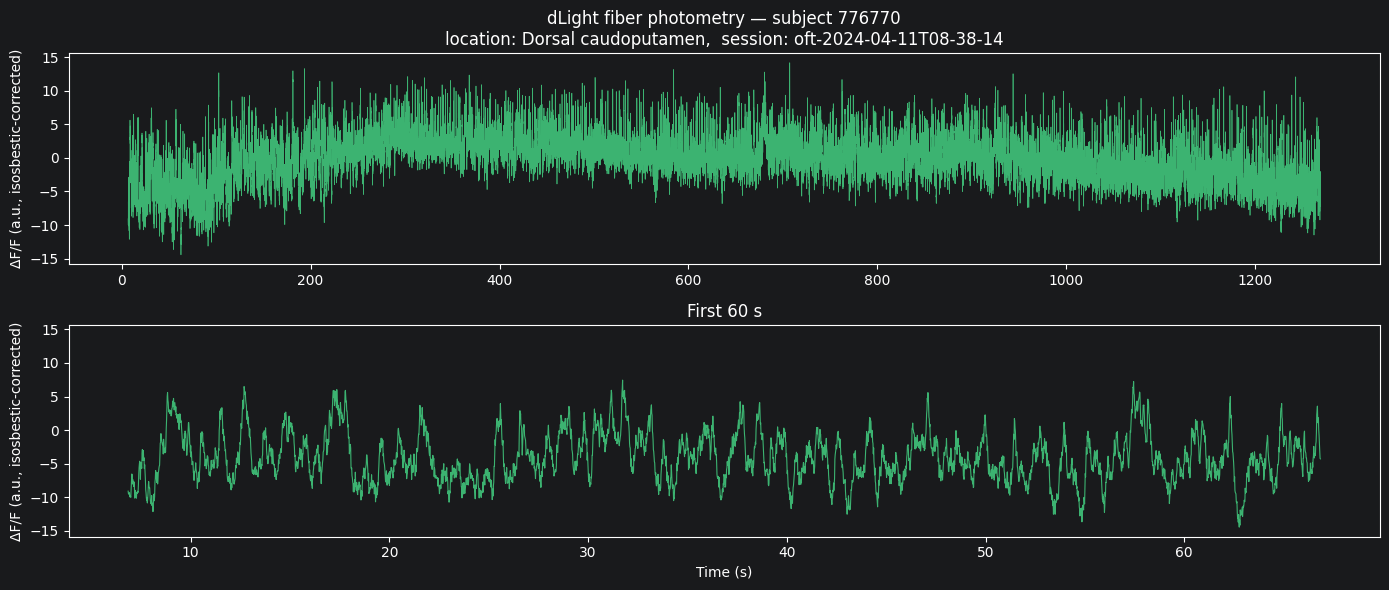

In [11]:
fp_table = nwbfile2.lab_meta_data["fiber_photometry"].fiber_photometry_table

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharey=True)

axes[0].plot(timestamps, signal, linewidth=0.5, color="mediumseagreen")
axes[0].set_ylabel("ΔF/F (a.u., isosbestic-corrected)")
axes[0].set_title(
    f"dLight fiber photometry — subject {nwbfile2.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile2.session_id}"
)

t_end = min(timestamps[0] + 60, timestamps[-1])
mask = timestamps <= t_end
axes[1].plot(timestamps[mask], signal[mask], linewidth=0.8, color="mediumseagreen")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("ΔF/F (a.u., isosbestic-corrected)")
axes[1].set_title("First 60 s")

plt.tight_layout()
plt.show()

#### Z-scored FP signal (30 Hz, aligned to behavior)

The `FiberPhotometrySeriesZScored` series stores the session-level z-scored signal at **30 Hz**,
aligned frame-by-frame to the behavioral data used for peri-event analyses.

Unit:          z-score
Rate:          30.000000000000107 Hz
Starting time: 6.87 s  (pre-recording frames excluded)
N samples:     37865
mean=0.0000  std=1.0000  range=[-4.200, 3.333]


/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_4801/3476189989.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


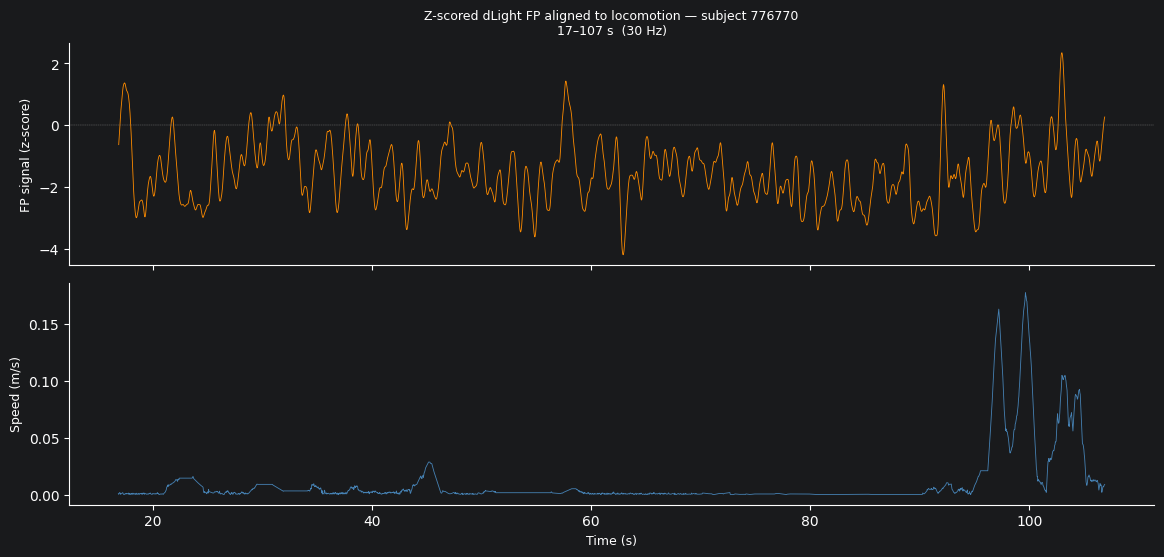

In [12]:
zs_series = nwbfile2.processing["ophys"]["FiberPhotometrySeriesZScored"]
zs_data   = zs_series.data[:]
zs_time   = zs_series.starting_time + np.arange(len(zs_data)) / zs_series.rate

print(f"Unit:          {zs_series.unit}")
print(f"Rate:          {zs_series.rate} Hz")
print(f"Starting time: {zs_series.starting_time:.2f} s  (pre-recording frames excluded)")
print(f"N samples:     {len(zs_data)}")
print(f"mean={zs_data.mean():.4f}  std={zs_data.std():.4f}  "
      f"range=[{zs_data.min():.3f}, {zs_data.max():.3f}]")

# Load speed directly so both signals can be plotted aligned on the same time axis
_kin_ts  = nwbfile2.processing["behavior"]["Kinematics"].time_series["linear_velocity"]
_speed   = _kin_ts.data[:] * _kin_ts.conversion
_speed_t = np.arange(len(_speed)) / _kin_ts.rate

# 90-second zoom window starting after FP warm-up
_t0 = float(zs_time[0]) + 10.0
_t1 = _t0 + 90.0
_zm_zs = (zs_time  >= _t0) & (zs_time  <= _t1)
_zm_sp = (_speed_t >= _t0) & (_speed_t <= _t1)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"hspace": 0.08})

axes[0].plot(zs_time[_zm_zs], zs_data[_zm_zs], linewidth=0.6, color="darkorange")
axes[0].axhline(0, color="gray", linewidth=0.3, linestyle="--")
axes[0].set_ylabel("FP signal (z-score)", fontsize=9)
axes[0].set_title(
    f"Z-scored dLight FP aligned to locomotion — subject {nwbfile2.subject.subject_id}\n"
    f"{_t0:.0f}–{_t1:.0f} s  (30 Hz)",
    fontsize=9,
)
axes[0].tick_params(labelbottom=False)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(_speed_t[_zm_sp], _speed[_zm_sp], linewidth=0.6, color="steelblue")
axes[1].set_ylabel(f"Speed ({_kin_ts.unit})", fontsize=9)
axes[1].set_xlabel("Time (s)", fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


#### Raw acquisition traces (470 nm signal + 405 nm isosbestic)

The raw fluorescence traces output directly by DoricStudio V5 are stored in `acquisition/`:

- **`FiberPhotometrySeriesRawSignal`** — 470 nm excitation, dopamine-sensitive dLight1.3b fluorescence
- **`FiberPhotometrySeriesIsosbesticControl`** — 405 nm isosbestic excitation, insensitive to dopamine;
  used as a motion artifact and photobleaching control

Both channels share the same sampling rate (~60 Hz) and starting time. The isosbestic-corrected
dF/F in `processing/ophys/` is derived from these two channels (470 nm − scaled 405 nm reference fit).

Signal (470 nm):    (75759,),  range [313.67, 756.40] a.u.
Reference (405 nm): (75759,),  range [214.16, 552.38] a.u.
Time range:         6.83 – 1269.47 s


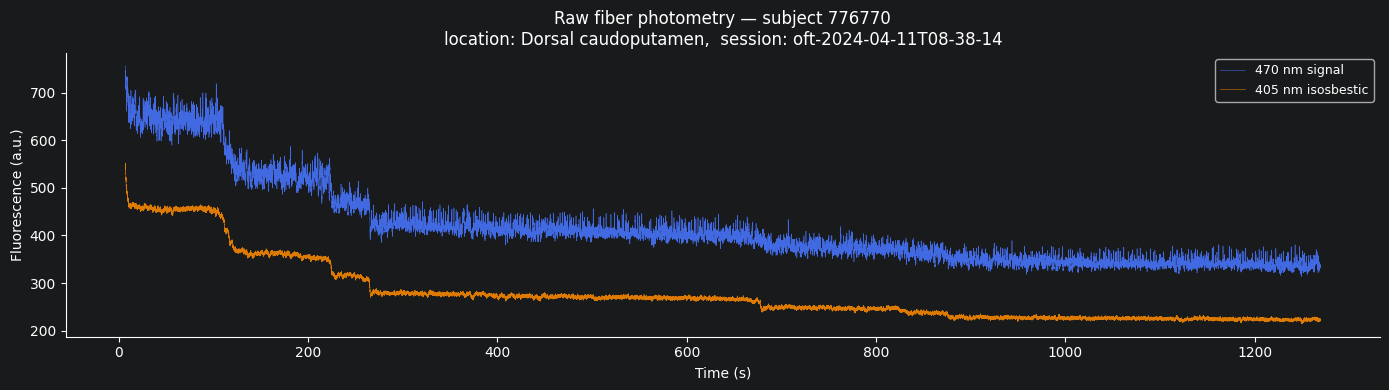

In [13]:
raw_sig = nwbfile2.acquisition["FiberPhotometrySeriesRawSignal"]
raw_ref = nwbfile2.acquisition["FiberPhotometrySeriesIsosbesticControl"]

sig_data = raw_sig.data[:]
ref_data = raw_ref.data[:]
raw_time = raw_sig.get_timestamps()

print(f"Signal (470 nm):    {sig_data.shape},  range [{sig_data.min():.2f}, {sig_data.max():.2f}] a.u.")
print(f"Reference (405 nm): {ref_data.shape},  range [{ref_data.min():.2f}, {ref_data.max():.2f}] a.u.")
print(f"Time range:         {raw_time[0]:.2f} – {raw_time[-1]:.2f} s")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_time, sig_data, linewidth=0.4, color="royalblue", label="470 nm signal")
ax.plot(raw_time, ref_data, linewidth=0.4, color="darkorange", alpha=0.85, label="405 nm isosbestic")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_xlabel("Time (s)")
ax.set_title(
    f"Raw fiber photometry — subject {nwbfile2.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile2.session_id}"
)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 2.2 Kinematics

Derived kinematics computed from the pose estimation data, stored in
`processing/behavior/Kinematics` as a `BehavioralTimeSeries` container at 30 Hz.

| Time series | Unit | Description |
|-------------|------|-------------|
| `linear_velocity` | m/s | Movement speed of the body center |
| `linear_acceleration` | m/s² | Movement acceleration of the body center |
| `angular_velocity` | rad/s | Angular speed of body orientation |
| `distance_moved` | m | Distance moved by the body center per frame |
| `angular_distance` | rad | Angular distance of body orientation change per frame |
| `linear_velocity_snout` | m/s | Movement speed of the snout |
| `distance_moved_snout` | m | Distance moved by the snout per frame |

In [14]:
behavior2 = nwbfile2.processing["behavior"]
kinematics = behavior2["Kinematics"]

print("Available kinematics time series:")
for name, ts in kinematics.time_series.items():
    data = ts.data[:] * ts.conversion
    print(f"  {name:25s}  shape={str(data.shape):12s}  unit={ts.unit:<12s}  range=[{np.nanmin(data):.4f}, {np.nanmax(data):.4f}]")

Available kinematics time series:
  angular_distance           shape=(38125,)      unit=rad           range=[0.0000, 2.5498]
  angular_velocity           shape=(38125,)      unit=rad/s         range=[0.0000, 76.4954]
  distance_moved             shape=(38125,)      unit=m             range=[0.0000, 0.0066]
  distance_moved_snout       shape=(38125,)      unit=m             range=[0.0000, 0.0061]
  linear_acceleration        shape=(38125,)      unit=m/s^2         range=[-0.5365, 0.7339]
  linear_velocity            shape=(38125,)      unit=m/s           range=[0.0000, 0.1969]
  linear_velocity_snout      shape=(38125,)      unit=m/s           range=[0.0000, 0.1826]


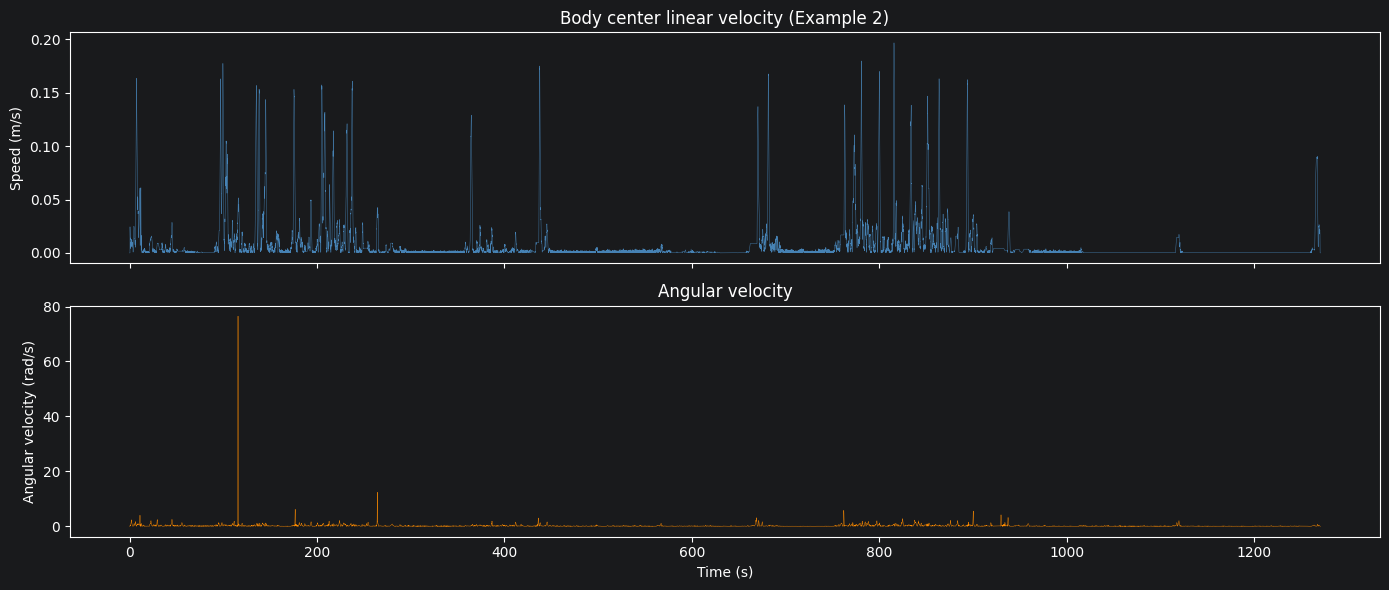

In [15]:
speed = kinematics.time_series["linear_velocity"]
speed_data = speed.data[:] * speed.conversion
speed_time = np.arange(len(speed_data)) / speed.rate

angular_speed = kinematics.time_series["angular_velocity"]
angular_data = angular_speed.data[:] * angular_speed.conversion

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(speed_time, speed_data, linewidth=0.3, color="steelblue")
axes[0].set_ylabel(f"Speed ({speed.unit})")
axes[0].set_title("Body center linear velocity (Example 2)")

axes[1].plot(speed_time, angular_data, linewidth=0.3, color="darkorange")
axes[1].set_ylabel(f"Angular velocity ({angular_speed.unit})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Angular velocity")

plt.tight_layout()
plt.show()

### 2.3 VAME behavioral motifs (sub-776770)

Sub-776770 was converted with the `VAME_42` model (42 k-means clusters; 39 of 42 clusters observed
in this session). Labels are stored in `processing/behavior/VAME_42` at 30 Hz.

> **⚠ Known artifact — motifs 18 and 25 (same as Example 1):** The degenerate pair described
> in §1.3 is present here as well. The pattern is identical: every occurrence of motif 18 is a
> single-frame run always followed by motif 25, which always transitions back to 18 or exits to
> motif 9 — forming the chain `… 41 → 18 → 25 → 9 …`. Treat motifs 18 and 25 as one state in
> any downstream analysis.

Project: VAME_42
MotifSeries shape: (38125,)  (1270.8 s at 30.000000000000007 Hz)
Unique motifs: 39  (labels 0–41)


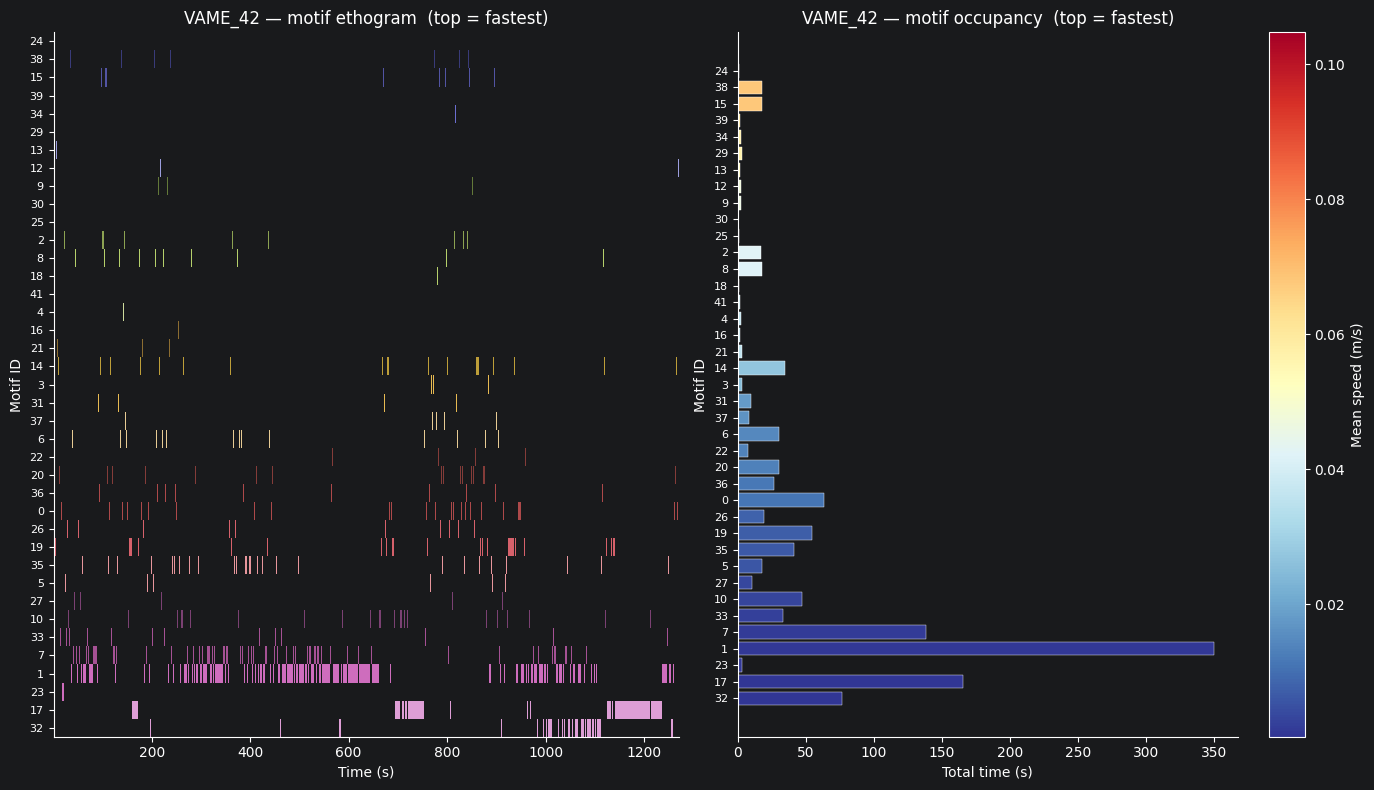

In [16]:
project2 = behavior2["VAME_42"]
ms2 = project2.motif_series["MotifSeries"]
labels2 = np.array(ms2.data[:])
time2 = ms2.get_timestamps()

print(f"Project: {project2.name}")
print(f"MotifSeries shape: {labels2.shape}  ({len(labels2) / ms2.rate:.1f} s at {ms2.rate} Hz)")
print(f"Unique motifs: {len(np.unique(labels2))}  (labels {labels2.min()}–{labels2.max()})")

unique2, counts2 = np.unique(labels2, return_counts=True)

# sort motifs by mean speed (fast → slow); speed_data loaded in §2.2
motif_mean2 = np.array([np.nanmean(speed_data[labels2 == m]) for m in unique2])
sort_idx2 = np.argsort(np.where(np.isfinite(motif_mean2), motif_mean2, -np.inf))[::-1]
sorted_ids2 = unique2[sort_idx2]
sorted_counts2 = counts2[sort_idx2]
sorted_means2 = motif_mean2[sort_idx2]

rank_map2 = {m: r for r, m in enumerate(sorted_ids2)}
rank_labels2 = np.array([rank_map2[l] for l in labels2])
yticks2 = np.arange(len(sorted_ids2))

norm2 = plt.Normalize(np.nanmin(sorted_means2), np.nanmax(sorted_means2))
bar_colors2 = plt.cm.RdYlBu_r(norm2(sorted_means2))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

_plot_ethogram(axes[0], time2, rank_labels2, yticks2, ms2.rate)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Motif ID")
axes[0].set_yticks(yticks2)
axes[0].set_yticklabels(sorted_ids2, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title(f"{project2.name} — motif ethogram  (top = fastest)")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(yticks2, sorted_counts2 / ms2.rate, color=bar_colors2, edgecolor="white", linewidth=0.3)
axes[1].set_yticks(yticks2)
axes[1].set_yticklabels(sorted_ids2, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_ylabel("Motif ID")
axes[1].set_xlabel("Total time (s)")
axes[1].set_title(f"{project2.name} — motif occupancy  (top = fastest)")
axes[1].spines[["top", "right"]].set_visible(False)
sm2 = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=norm2)
plt.colorbar(sm2, ax=axes[1], label="Mean speed (m/s)")

plt.tight_layout()
plt.show()

#### 2.3e Recommended: merge degenerate pairs on the fly

The NWB file stores the raw VAME_42 labels (39 observed motifs) as the canonical record.
For analysis, degenerate pairs — motifs with virtually identical kinematics that always
alternate frame-by-frame due to a k-means boundary artifact — should be collapsed into a
single label using the merge map below.

```python
merge_map = {15: 38, 2: 8, 29: 34, 18: 25}
labels_merged = np.array([merge_map.get(int(l), int(l)) for l in labels])
```

| Absorbed | → | Kept | Evidence |
|----------|---|------|---------|
| 15 | → | 38 | Merged in aligned CSV; single-frame runs, deterministic alternation, cosine similarity ≈ 1.0 |
| 2  | → | 8  | Merged in aligned CSV; same pattern |
| 29 | → | 34 | Merged in aligned CSV; same pattern |
| 18 | → | 25 | **Not** merged in CSV (oversight); identical artifact pattern confirmed in raw `.npy` files |

This yields **35 motifs** — one fewer than the CSV (36), because 18/25 was not caught in the
lab's original curation. The published analyses in Mantas et al. (2026) used the 36-motif CSV
vocabulary; this 35-motif set is the fully-corrected version.

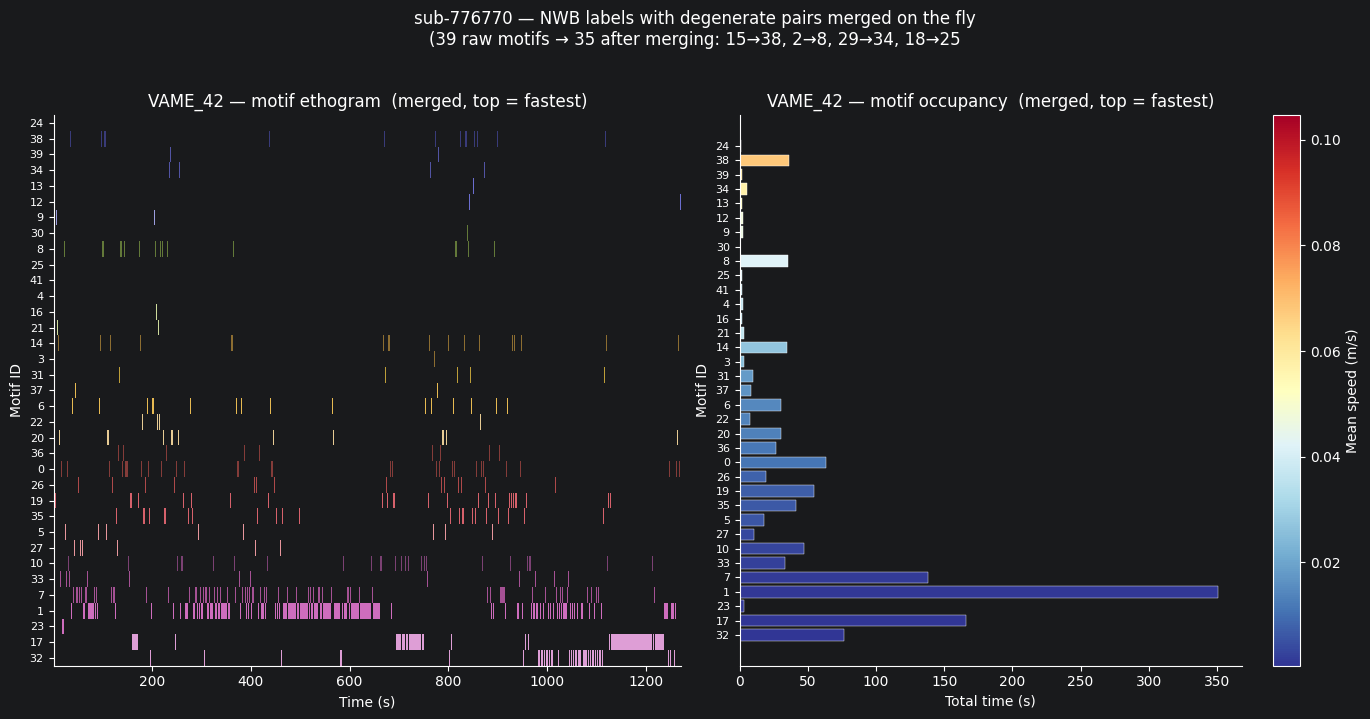

Raw NWB labels:    39 unique motifs
After merge:       35 unique motifs
Merge applied:     {15: 38, 2: 8, 29: 34, 18: 25}


In [17]:
# Merge map: degenerate pairs confirmed in raw .npy files and aligned CSV
# 18→25 is added here — the CSV missed this pair, so the published analyses
# still treat them as separate; merge before any downstream analysis.
merge_map = {15: 38, 2: 8, 29: 34, 18: 25}

labels2_merged = np.array([merge_map.get(int(l), int(l)) for l in labels2])

unique_m, counts_m = np.unique(labels2_merged, return_counts=True)
motif_mean_m = np.array([np.nanmean(speed_data[labels2_merged == m]) for m in unique_m])
sort_idx_m   = np.argsort(np.where(np.isfinite(motif_mean_m), motif_mean_m, -np.inf))[::-1]
sorted_ids_m  = unique_m[sort_idx_m]
sorted_cnts_m = counts_m[sort_idx_m]
sorted_means_m= motif_mean_m[sort_idx_m]

rank_map_m    = {m: r for r, m in enumerate(sorted_ids_m)}
rank_labels_m = np.array([rank_map_m[l] for l in labels2_merged])
yticks_m      = np.arange(len(sorted_ids_m))

norm_m   = plt.Normalize(np.nanmin(sorted_means_m), np.nanmax(sorted_means_m))
colors_m = plt.cm.RdYlBu_r(norm_m(sorted_means_m))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

_plot_ethogram(axes[0], time2, rank_labels_m, yticks_m, ms2.rate)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Motif ID")
axes[0].set_yticks(yticks_m)
axes[0].set_yticklabels(sorted_ids_m, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title(f"{project2.name} — motif ethogram  (merged, top = fastest)")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(yticks_m, sorted_cnts_m / ms2.rate, color=colors_m, edgecolor="white", linewidth=0.3)
axes[1].set_yticks(yticks_m)
axes[1].set_yticklabels(sorted_ids_m, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_ylabel("Motif ID")
axes[1].set_xlabel("Total time (s)")
axes[1].set_title(f"{project2.name} — motif occupancy  (merged, top = fastest)")
axes[1].spines[["top", "right"]].set_visible(False)
plt.colorbar(plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=norm_m), ax=axes[1], label="Mean speed (m/s)")

plt.suptitle(
    f"sub-776770 — NWB labels with degenerate pairs merged on the fly\n"
    f"({len(np.unique(labels2))} raw motifs → {len(unique_m)} after merging: "
    + ", ".join(f"{k}→{v}" for k, v in merge_map.items()),
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"Raw NWB labels:    {len(np.unique(labels2))} unique motifs")
print(f"After merge:       {len(unique_m)} unique motifs")
print(f"Merge applied:     {merge_map}")

### 2.6 Combined dF/F and velocity trace

Both signals share the same time reference (synchronized by Bonsai at session start).
The dF/F signal is globally z-scored for display; velocity is plotted in the native unit
stored in the NWB file. FP timestamps begin at ~7 s due to system warm-up.

The zoomed panel (bottom row) shows a 60-second representative window to make the
sub-second co-modulation visible.

/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_4801/233760750.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


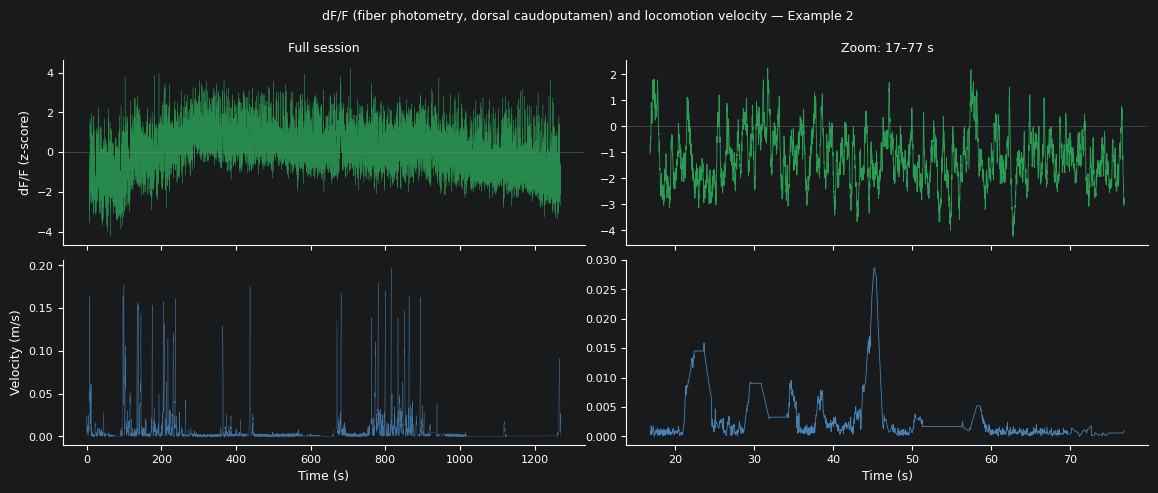

In [18]:
# Z-score dF/F for display
signal_z = (signal - signal.mean()) / signal.std()

# Choose a 60-second zoom window starting where FP is stable
_t0_zoom = float(timestamps[0]) + 10.0
_t1_zoom = _t0_zoom + 60.0

fig_comb, axes_comb = plt.subplots(
    2, 2,
    figsize=(14, 5),
    sharex="col",
    gridspec_kw={"wspace": 0.08, "hspace": 0.08},
)

# ---------- full session (left column) ----------
axes_comb[0, 0].plot(timestamps, signal_z, linewidth=0.25, color="#2a9d54", alpha=0.85)
axes_comb[0, 0].set_ylabel("dF/F (z-score)", fontsize=9)
axes_comb[0, 0].set_title("Full session", fontsize=9)
axes_comb[0, 0].axhline(0, color="gray", linewidth=0.4, linestyle="--")

axes_comb[1, 0].plot(speed_time, speed_data, linewidth=0.25, color="steelblue", alpha=0.85)
axes_comb[1, 0].set_ylabel(f"Velocity ({speed.unit})", fontsize=9)
axes_comb[1, 0].set_xlabel("Time (s)", fontsize=9)

# ---------- 60-second zoom (right column) ----------
_fp_mask = (timestamps >= _t0_zoom) & (timestamps <= _t1_zoom)
_vel_mask = (speed_time >= _t0_zoom) & (speed_time <= _t1_zoom)

axes_comb[0, 1].plot(timestamps[_fp_mask], signal_z[_fp_mask], linewidth=0.6, color="#2a9d54")
axes_comb[0, 1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes_comb[0, 1].set_title(f"Zoom: {_t0_zoom:.0f}–{_t1_zoom:.0f} s", fontsize=9)

axes_comb[1, 1].plot(speed_time[_vel_mask], speed_data[_vel_mask], linewidth=0.6, color="steelblue")
axes_comb[1, 1].set_xlabel("Time (s)", fontsize=9)

for ax in axes_comb.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

fig_comb.suptitle(
    "dF/F (fiber photometry, dorsal caudoputamen) and locomotion velocity — Example 2",
    fontsize=9,
)
plt.tight_layout()
plt.show()


In [19]:
io1.close()
io2.close()